# Data Preprocessing
In this notebook, we will create the PyTorch `DataLoader`s and apply image augmentation to the training set. This prepares our data to be fed into the CNN.


In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Define Image Transformations
We will apply Data Augmentation strictly to the training data to prevent overfitting. We will use random horizontal flips and slight random rotations. For both train and test data, we will convert the images to tensors and normalize their pixel values.


In [2]:
# The FER-2013 images are 48x48 grayscale. We ensure they are loaded as grayscale.

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize pixels between -1 and 1
])

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

## 2. Create Datasets and DataLoaders
We use PyTorch's `ImageFolder` to automatically load the images and infer the class labels from the folder names.


In [3]:
dataset_path = Path('../dataset')
train_dir = dataset_path / 'train'
test_dir = dataset_path / 'test'

batch_size = 64

train_dataset = ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = ImageFolder(root=test_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Training dataset size: {len(train_dataset)} images")
print(f"Testing dataset size: {len(test_dataset)} images")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")

Training dataset size: 28709 images
Testing dataset size: 7178 images
Number of classes: 7
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 3. Visualize Augmented Batch
Let's pull one batch of data from our `train_loader` to verify that our augmentation and normalization are working correctly.


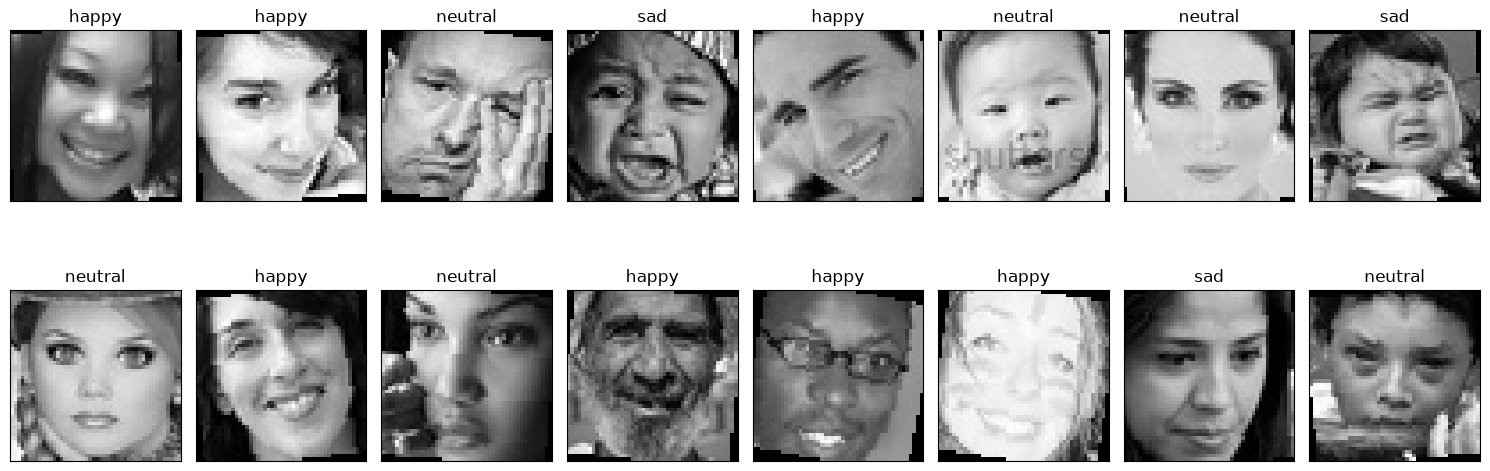

In [4]:
def imshow(img):
    # Un-normalize the image
    img = img * 0.5 + 0.5     
    npimg = img.numpy()
    plt.imshow(np.squeeze(npimg), cmap='gray')

# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(15, 6))
# Show top 16 images from the batch
for idx in np.arange(16):
    ax = fig.add_subplot(2, 8, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(train_dataset.classes[labels[idx]])

plt.tight_layout()
plt.savefig('../visualizations/augmented_batch.png')
plt.show()